In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [33]:
def power_method(A, v0, iters, basis, tol=1e-15):
    
    if A.shape[0] != A.shape[1]:
        raise ValueError("A must be quadratic")
        
    if not np.allclose(A.T, A):
        raise ValueError("A must be symmetric")
        
    v0_norm = np.linalg.norm(v0)
    
    if v0_norm < tol:
        raise ValueError("Starting vector is the zero vector")
        
    v0 = v0 / v0_norm

    for _ in range(iters):
        v = A @ v0
        
        for x in basis:
            v -= (v.T @ x) * x
        
        v_norm = np.linalg.norm(v)
        
        if v_norm < tol:
            return 0.0, v0
        
        v0 = v / v_norm
    
    lam = v0.T @ A @ v0
        
    return lam, v0

In [34]:
def rand_power_method(A, iters):
    
    n = A.shape[0]
    v0 = np.random.randn(n)
    v0 = v0 / np.linalg.norm(v0)
    
    return power_method(A, v0, iters, basis, tol=1e-15)

In [35]:
reps = 50
n = 10
iters = 1000
all_eigvals = []
all_eigvecs = []

for rep in range(reps):
    
    eigvals = []
    eigvecs = []
    
    X = np.random.normal(0.0, 1.0, size=(n,n))
    W = X.T @ X
    
    for _ in range(n):
        v0 = np.random.randn(n)
        
        lam, v = power_method(W, v0, iters, eigvecs, tol=1e-15)
        
        eigvals.append(lam)
        eigvecs.append(v)
        
    all_eigvals.append(eigvals)
    all_eigvecs.append(eigvecs)

all_eigvals = np.sort(np.array(all_eigvals), axis=1)[:, ::-1] # shape: (50, 10)
all_eigvecs = np.array(all_eigvecs) # shape: (50, 10, 10)

6.022302268778079e-16
1.0658141036401503e-14


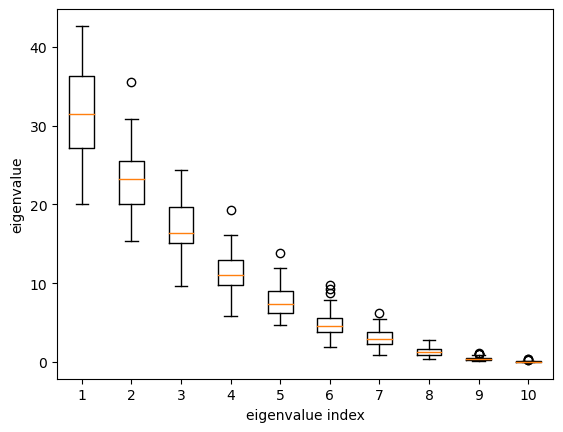

In [36]:
# check orthogonality
Q = np.column_stack(eigvecs)
print(np.linalg.norm(Q.T @ Q - np.eye(n)))

# check eigenvalue error
true_eigs = np.linalg.eigvalsh(W)[::-1]
print(np.max(np.abs(true_eigs - all_eigvals[-1])))

plt.boxplot(all_eigvals)
plt.xlabel("eigenvalue index")
plt.ylabel("eigenvalue")
plt.show()